In [19]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
from random import gauss as rgauss
import numpy as np
from scipy.stats.mstats import gmean
from tqdm.notebook import tqdm
import pingouin as pg

pd.DataFrame.iteritems = pd.DataFrame.items

In [20]:
def mgauss(mu=1, sigma=.1, threshold=2):
    """This limits the generated values within ± <threshold> standard deviations
    """
    
    val = mu + sigma * threshold * 2

    while abs(val - mu) > sigma * threshold: 
        val = rgauss(mu, sigma)

    return val

In [21]:
# params
# ======

teer_std = 0.15     # standard deviation of TEER

teer_ctrl = 1       # TEER of control CM
teer_sema6a = 0.6   # TEER of SEMA6A-enriched CM
teer_kd = 0.8       # estimated TEER of SEMA6A-enriched CM upon KD (+20% vs sema6a)

<Axes: >

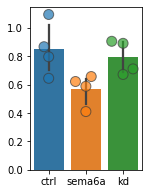

In [22]:
#plot an example

n = 4         # sample size per experimental group

ctrl      = [mgauss(mu=teer_ctrl,   sigma=teer_std * teer_ctrl,   threshold=3) for _ in range(n)]
sema6a    = [mgauss(mu=teer_sema6a, sigma=teer_std * teer_sema6a, threshold=3) for _ in range(n)]
kd        = [mgauss(mu=teer_kd,     sigma=teer_std * teer_kd,     threshold=3) for _ in range(n)]

repack = {"ctrl": ctrl, "sema6a": sema6a, "kd": kd}
repack = pd.DataFrame(repack, index=range(n))

plt.figure(figsize=(2,3))
sns.barplot(data=repack)
sns.swarmplot(data=repack, s=10, linewidth=1, alpha=.7)

In [23]:
#compute p-values for ttest and Tukey's post-hoc test over 1000 simulations for different sample sizes

n_values = [3, 4, 5, 6, 7, 8, 9, 10]

t_power = []
a1_power = []
a2_power = []

for n in n_values:
    t_pvals = []
    a1_pvals = []
    a2_pvals = []

    n_sims = 1000
    for i in tqdm(range(n_sims)):
        ctrl      = [mgauss(mu=teer_ctrl,   sigma=teer_std * teer_ctrl,   threshold=3) for _ in range(n)]
        sema6a    = [mgauss(mu=teer_sema6a, sigma=teer_std * teer_sema6a, threshold=3) for _ in range(n)]
        kd        = [mgauss(mu=teer_kd,     sigma=teer_std * teer_kd,     threshold=3) for _ in range(n)]
    
        t_res = pg.ttest(ctrl, sema6a)
        t_pval = t_res["p-val"].iloc[0]
        t_pvals.append(t_pval)

        repacked_vals = ctrl + sema6a + kd
        repacked_hues = ["ctrl" for _ in range(n)] + ["sema6a" for _ in range(n)] + ["kd" for _ in range(n)]
        repack = {"vals": repacked_vals, "tags": repacked_hues}
        repack = pd.DataFrame(repack, index=range(n * 3))
        #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
        posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
        a1_pval = posthoc[(posthoc["A"] == "ctrl") &  (posthoc["B"] == "sema6a")]["p-corr"].iloc[0]
        a1_pvals.append(a1_pval)
        a2_pval = posthoc[(posthoc["A"] == "kd") &  (posthoc["B"] == "sema6a")]["p-corr"].iloc[0]
        a2_pvals.append(a2_pval)
        
    t = np.array(t_pvals)
    a1 = np.array(a1_pvals)
    a2 = np.array(a2_pvals)  
    
    t_pow = sum(t < .05)
    a1_pow = sum(a1 < .05)
    a2_pow = sum(a2 < .05)
    
    t_power.append(t_pow)
    a1_power.append(a1_pow)
    a2_power.append(a2_pow)
    
    print(f"For n = {n} the power of ttest is {sum(t < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between ctrl and sema6a is {sum(a1 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between sema6a and kd is {sum(a2 < .05)/10}%")

  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 3 the power of ttest is 83.5%
For n = 3 the power of Tukey's post-hoc test between ctrl and sema6a is 66.0%
For n = 3 the power of Tukey's post-hoc test between sema6a and kd is 35.3%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 4 the power of ttest is 97.4%
For n = 4 the power of Tukey's post-hoc test between ctrl and sema6a is 89.1%
For n = 4 the power of Tukey's post-hoc test between sema6a and kd is 55.6%


  0%|          | 0/1000 [00:00<?, ?it/s]

...

For n = 8 the power of ttest is 100.0%
For n = 8 the power of Tukey's post-hoc test between ctrl and sema6a is 100.0%
For n = 8 the power of Tukey's post-hoc test between sema6a and kd is 94.3%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 9 the power of ttest is 100.0%
For n = 9 the power of Tukey's post-hoc test between ctrl and sema6a is 100.0%
For n = 9 the power of Tukey's post-hoc test between sema6a and kd is 96.5%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 10 the power of ttest is 100.0%
For n = 10 the power of Tukey's post-hoc test between ctrl and sema6a is 100.0%
For n = 10 the power of Tukey's post-hoc test between sema6a and kd is 97.8%


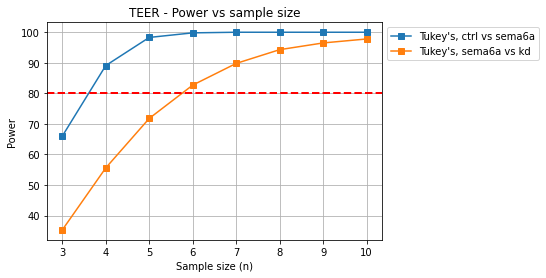

In [24]:
plt.figure()

#plt.plot(n_values, np.array(t_power), marker='o', label='t-test')
plt.plot(n_values, np.array(a1_power)/10, marker='s', label="Tukey's, ctrl vs sema6a")
plt.plot(n_values, np.array(a2_power)/10, marker='s', label="Tukey's, sema6a vs kd")

plt.xlabel('Sample size (n)')
plt.ylabel('Power')
plt.title('TEER - Power vs sample size')

threshold = 80
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.show()